In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder


# Zadanie 1:  

## Email Spam

 Masz dane o 12 emailach z informacją czy to spam czy nie:

 **Zadania do wykonania:**

**a) Ręczne obliczenia**
1. Oblicz prawdopodobieństwa a priori: P(Spam=TAK) i P(Spam=NIE)
2. Dla każdej cechy oblicz prawdopodobieństwa warunkowe
3. Przewidź klasę dla nowego emaila:
```
   Słowo_1 = 'darmowy'
   Słowo_2 = 'wygrana'  
   Wykrzyknik = 'TAK'
```

Oblicz prawdopodobieństwa dla obu klas (TAK lub NIE) i znormalizuj

**b) Implementacja w Python**

1. Zaimplementuj obliczenia z punktu a) w Python (bez sklearn)
2. Porównaj wyniki z ręcznymi obliczeniami

**c) Sklearn**

1. Użyj `CategoricalNB` z sklearn do wytrenowania modelu
2. Porównaj wyniki z własnymi obliczeniami
3. Wyjaśnij różnice (jeśli są)

In [4]:
data_spam = {
    'Słowo_1': ['darmowy', 'darmowy', 'spotkanie', 'raport', 'oferta', 'darmowy',
                'spotkanie', 'oferta', 'raport', 'darmowy', 'spotkanie', 'oferta'],
    'Słowo_2': ['wygrana', 'wygrana', 'jutro', 'kwartalny', 'specjalna', 'rabat',
                'dziś', 'limitowana', 'miesięczny', 'rabat', 'pilne', 'wyjątkowa'],
    'Wykrzyknik': ['TAK', 'TAK', 'NIE', 'NIE', 'TAK', 'TAK',
                   'NIE', 'TAK', 'NIE', 'TAK', 'NIE', 'TAK'],
    'Spam': ['TAK', 'TAK', 'NIE', 'NIE', 'NIE', 'TAK',
             'NIE', 'NIE', 'NIE', 'TAK', 'NIE', 'NIE']
}

df = pd.DataFrame(data_spam)

# a) Ręczne obliczenia

* Dane:
  * N - liczba maili
  * N = 12
  * Ntak = 4
  * Nnie = 8

1. A priori:
  * P(Spam = TAK) = Ntak/N = 4/12 = 1/3 = 0.33333
  * P(Spam = NIE) = Nnie/N = 8/12 = 2/3 = 0.66666

2. Prawdopodobieństwo warunkowe:
  * Słowo_1
    * Spam = TAK
      * P(Słowo_1 = darmowy | Spam = TAK) = 4/4 = 1
      * P(Słowo_1 = spotkanie | Spam = TAK) = 0/4 = 0
      * P(Słowo_1 = raport | Spam = TAK) = 0/4 = 0
      * P(Słowo_1 = oferta | Spam = TAK) = 0/4 = 0
    * Spam = NIE
      * P(Słowo_1 = darmowy | Spam = NIE) = 0/8 = 0
      * P(Słowo_1 = spotkanie | Spam = NIE) = 3/8
      * P(Słowo_1 = raport | Spam = NIE) = 2/8 = 1/4
      * P(Słowo_1 = oferta | Spam = NIE) = 3/8
  * Słowo_2
    * Spam = TAK
      * P(Słowo_2 = wygrana | Spam = TAK) = 2/4 = 1/2
      * P(Słowo_2 = rabat | Spam = TAK) = 2/4 = 1/2
      * P(Słowo_2 = <pozostałe> | Spam = TAK) = 0/4 = 0
    * Spam = NIE
      * P(Słowo_2 = wygrana | Spam = NIE) = 0/8 = 0
      * P(Słowo_2 = rabat | Spam = NIE) = 0/8 = 0
      * P(Słowo_2 = <pozostałe> | Spam = NIE) = 1/8
  * Wykrzyknik
    * Spam = TAK
      * P(Wykrzyknik = TAK | Spam = TAK) = 4/4 = 1
      * P(Wykrzyknik = NIE | Spam = TAK) = 0/4 = 0
    * Spam = NIE
      * P(Wykrzyknik = TAK | Spam = NIE) = 3/8
      * P(Wykrzyknik = NIE | Spam = NIE) = 5/8

3. Score:
{
  Słowo_1 = 'darmowy'
  Słowo_2 = 'wygrana'  
  Wykrzyknik = 'TAK'
}

score(TAK) = P(Spam=TAK) * P(Słowo_1=darmowy|TAK) * P(Słowo_2=wygrana|TAK) * P(Wykrzyknik=TAK|TAK) = 4/12 * 1 * 1/2 * 1 = 1/6 = 0.16666

score(NIE) = P(Spam=NIE) * P(Słowo_1=darmowy|NIE) * P(Słowo_2=wygrana|NIE) * P(Wykrzyknik=TAK|NIE) = 8/12 * 0 * 0 * 3/8 = 0

4. Normalizacja

suma = score(TAK)+score(NIE) = 1/6
P(Spam = TAK|cechy) = score(TAK)/suma = 1
P(Spam = NIE|cechy) = score(NIE)/suma = 0

5. Predykcja

Jak widac powyżej dla nowego emaila z założonymi parametrami argmax = 1 dla P(Spam = TAK|cechy), co za tym idzie zostanie on przypisany do klasy Spam = TAK.

# b) Implementacja w Python

In [5]:
# Oblicz prawdopodobieństwa a priori: P(Spam=TAK) i P(Spam=NIE)
class_counts = df['Spam'].value_counts()
total = len(df)
priors = class_counts / total

print(f"Liczba przypadków TAK: {class_counts['TAK']}")
print(f"Liczba przypadków NIE: {class_counts['NIE']}")
print(f"Razem: {total}")
print()
print(f"P(Spam = TAK) = {class_counts['TAK']}/{total} = {priors['TAK']:.3f}")
print(f"P(Spam = NIE) = {class_counts['NIE']}/{total} = {priors['NIE']:.3f}")
print()

Liczba przypadków TAK: 4
Liczba przypadków NIE: 8
Razem: 12

P(Spam = TAK) = 4/12 = 0.333
P(Spam = NIE) = 8/12 = 0.667



In [6]:
# Dla każdej cechy oblicz prawdopodobieństwa warunkowe
features = ['Słowo_1', 'Słowo_2', 'Wykrzyknik']
conditionals = {}

for feature in features:
    print(f"\n{'='*60}")
    print(f"Cecha: {feature.upper()}")
    print(f"{'='*60}")
    conditionals[feature] = {}

    for class_val in ['TAK', 'NIE']:
        class_data = df[df['Spam'] == class_val]
        class_count = len(class_data)

        print(f"\nDla klasy {class_val} ({class_count} przypadków):")
        print("-" * 40)

        conditionals[feature][class_val] = {}
        feature_counts = class_data[feature].value_counts()

        for feature_val in df[feature].unique():
            count = feature_counts.get(feature_val, 0)
            prob = count / class_count
            conditionals[feature][class_val][feature_val] = prob

            print(f"  {feature_val:12s}: {count} przypadków → "
                  f"P({feature}={feature_val} | {class_val}) = "
                  f"{count}/{class_count} = {prob:.3f}")


Cecha: SŁOWO_1

Dla klasy TAK (4 przypadków):
----------------------------------------
  darmowy     : 4 przypadków → P(Słowo_1=darmowy | TAK) = 4/4 = 1.000
  spotkanie   : 0 przypadków → P(Słowo_1=spotkanie | TAK) = 0/4 = 0.000
  raport      : 0 przypadków → P(Słowo_1=raport | TAK) = 0/4 = 0.000
  oferta      : 0 przypadków → P(Słowo_1=oferta | TAK) = 0/4 = 0.000

Dla klasy NIE (8 przypadków):
----------------------------------------
  darmowy     : 0 przypadków → P(Słowo_1=darmowy | NIE) = 0/8 = 0.000
  spotkanie   : 3 przypadków → P(Słowo_1=spotkanie | NIE) = 3/8 = 0.375
  raport      : 2 przypadków → P(Słowo_1=raport | NIE) = 2/8 = 0.250
  oferta      : 3 przypadków → P(Słowo_1=oferta | NIE) = 3/8 = 0.375

Cecha: SŁOWO_2

Dla klasy TAK (4 przypadków):
----------------------------------------
  wygrana     : 2 przypadków → P(Słowo_2=wygrana | TAK) = 2/4 = 0.500
  jutro       : 0 przypadków → P(Słowo_2=jutro | TAK) = 0/4 = 0.000
  kwartalny   : 0 przypadków → P(Słowo_2=kwartalny | T

In [7]:
# Tabela prawdopodobieństw
for feature in features:
    print(f"\n{feature.upper()}:")
    print("-" * 60)
    print(f"{'Wartość':15s} | P({feature}|TAK) | P({feature}|NIE)")
    print("-" * 60)

    for val in df[feature].unique():
        prob_tak = conditionals[feature]['TAK'].get(val, 0)
        prob_nie = conditionals[feature]['NIE'].get(val, 0)
        print(f"{val:15s} | {prob_tak:13.3f} | {prob_nie:13.3f}")


SŁOWO_1:
------------------------------------------------------------
Wartość         | P(Słowo_1|TAK) | P(Słowo_1|NIE)
------------------------------------------------------------
darmowy         |         1.000 |         0.000
spotkanie       |         0.000 |         0.375
raport          |         0.000 |         0.250
oferta          |         0.000 |         0.375

SŁOWO_2:
------------------------------------------------------------
Wartość         | P(Słowo_2|TAK) | P(Słowo_2|NIE)
------------------------------------------------------------
wygrana         |         0.500 |         0.000
jutro           |         0.000 |         0.125
kwartalny       |         0.000 |         0.125
specjalna       |         0.000 |         0.125
rabat           |         0.500 |         0.000
dziś            |         0.000 |         0.125
limitowana      |         0.000 |         0.125
miesięczny      |         0.000 |         0.125
pilne           |         0.000 |         0.125
wyjątkowa   

In [8]:
# Przewidź klasę dla nowego emaila:
new_record = {
    'Słowo_1': 'darmowy',
    'Słowo_2': 'wygrana',
    'Wykrzyknik': 'TAK'
}
# new_record = {
#     'Słowo_1': 'oferta',
#     'Słowo_2': 'wyjątkowa',
#     'Wykrzyknik': 'TAK'
# }

print(f"\nNowy rekord:")
for key, val in new_record.items():
    print(f"  {key}: {val}")
print()

scores = {}

for class_val in ['TAK', 'NIE']:
    print(f"\n{'='*60}")
    print(f"Obliczenia dla klasy: {class_val}")
    print(f"{'='*60}")

    score = priors[class_val]
    print(f"\n1. Prior: P({class_val}) = {score:.3f}")

    step = 2
    for feature, value in new_record.items():
        prob = conditionals[feature][class_val].get(value, 0)
        print(f"{step}. P({feature}={value} | {class_val}) = {prob:.3f}")
        score *= prob
        print(f"   Score po mnożeniu: {score:.6f}")
        step += 1

    print(f"\nWynik końcowy dla {class_val}: {score:.6f}")
    scores[class_val] = score



Nowy rekord:
  Słowo_1: darmowy
  Słowo_2: wygrana
  Wykrzyknik: TAK


Obliczenia dla klasy: TAK

1. Prior: P(TAK) = 0.333
2. P(Słowo_1=darmowy | TAK) = 1.000
   Score po mnożeniu: 0.333333
3. P(Słowo_2=wygrana | TAK) = 0.500
   Score po mnożeniu: 0.166667
4. P(Wykrzyknik=TAK | TAK) = 1.000
   Score po mnożeniu: 0.166667

Wynik końcowy dla TAK: 0.166667

Obliczenia dla klasy: NIE

1. Prior: P(NIE) = 0.667
2. P(Słowo_1=darmowy | NIE) = 0.000
   Score po mnożeniu: 0.000000
3. P(Słowo_2=wygrana | NIE) = 0.000
   Score po mnożeniu: 0.000000
4. P(Wykrzyknik=TAK | NIE) = 0.375
   Score po mnożeniu: 0.000000

Wynik końcowy dla NIE: 0.000000


In [9]:
# Normalizacja
print("\n" + "=" * 60)
print("NORMALIZACJA I WYNIK KOŃCOWY")
print("=" * 60)

total_score = sum(scores.values())
print(f"\nSuma scores: {scores['TAK']:.6f} + {scores['NIE']:.6f} = {total_score:.6f}")
print()

normalized = {k: v/total_score for k, v in scores.items()}

print("Prawdopodobieństwa po normalizacji:")
for class_val in ['TAK', 'NIE']:
    percentage = normalized[class_val] * 100
    print(f"  P({class_val} | cechy) = {scores[class_val]:.6f} / {total_score:.6f} = "
          f"{normalized[class_val]:.3f} = {percentage:.1f}%")

print("\n" + "=" * 60)
prediction = max(normalized, key=normalized.get)
print(f"PREDYKCJA: {prediction}")
print(f"Pewność: {normalized[prediction]*100:.1f}%")
print("=" * 60)


NORMALIZACJA I WYNIK KOŃCOWY

Suma scores: 0.166667 + 0.000000 = 0.166667

Prawdopodobieństwa po normalizacji:
  P(TAK | cechy) = 0.166667 / 0.166667 = 1.000 = 100.0%
  P(NIE | cechy) = 0.000000 / 0.166667 = 0.000 = 0.0%

PREDYKCJA: TAK
Pewność: 100.0%


* Porównaj wyniki z ręcznymi obliczeniami
  * Wyniki otrzymany przy pomocy obliczeń z wykorzystaniem pythona pokrywają się z tymi otrzymanymi z ręcznych obliczeń.

# c) Sklearn

In [10]:
# Użyj CategoricalNB z sklearn do wytrenowania modelu
le_dict = {}
features = ['Słowo_1', 'Słowo_2', 'Wykrzyknik']
X_encoded = df[features].copy()

for col in features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(df['Spam'])

model = CategoricalNB()
model.fit(X_encoded, y_encoded)

new_record = {
    'Słowo_1': 'darmowy',
    'Słowo_2': 'wygrana',
    'Wykrzyknik': 'TAK'
}

new_record_encoded = []
for feature in features:
    value = new_record[feature]
    encoded_value = le_dict[feature].transform([value])[0]
    new_record_encoded.append(encoded_value)

new_record_array = np.array([new_record_encoded])

prediction = model.predict(new_record_array)
probabilities = model.predict_proba(new_record_array)

print("\n" + "=" * 60)
print("WERYFIKACJA ZE SKLEARN")
print("=" * 60)
print(f"Predykcja: {le_target.inverse_transform(prediction)[0]}")
print(f"Prawdopodobieństwa: TAK={probabilities[0][1]:.3f}, NIE={probabilities[0][0]:.3f}")


WERYFIKACJA ZE SKLEARN
Predykcja: TAK
Prawdopodobieństwa: TAK=0.968, NIE=0.032


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


* Porównaj wyniki z własnymi obliczeniami
  * Predykcja się zgadza i nowy email został przyporządkowany do tej samej klasy co w przypadku ręcznych czy pythonowym obliczeń. Różnicę stanowią jednak współczynniki prawdopodobieństw.

* Wyjaśnij różnice (jeśli są)
  * Różnica wynika z zastosowania Laplace Smoothing (wygładzenia), który dodaje małą "pseudo-liczbę" (α w sklear domyśłnie równy 1) do każdej kategorii pomnożoną przez liczba kategorii dla danej cechy. W efekcie model jest bardziej "ostrożny" w predykcjach i lepiej generalizuje a prawdopodobieństwa warunkowe nigdy nie są równe 0.


# Zadanie 2

## Diagnoza grypy

Lekarz diagnozuje grypę na podstawie objawów u 15 pacjentów:

a) Analiza danych

1. Ile przypadków grypy jest w danych?
2. Która cecha najbardziej "wskazuje" na grypę? (porównaj P(cecha|TAK) vs P(cecha|NIE))
3. Stwórz wizualizację rozkładów cech dla każdej klasy

b) Predykcja dla 3 pacjentów
Dla każdego pacjenta oblicz prawdopodobieństwo grypy:
* Pacjent A: Gorączka=wysoka, Kaszel=TAK, Zmęczenie=duże
* Pacjent B: Gorączka=niska, Kaszel=NIE, Zmęczenie=małe
* Pacjent C: Gorączka=umiarkowana, Kaszel=TAK, Zmęczenie=umiarkowane

In [12]:
data = {
    'Gorączka': ['wysoka', 'wysoka', 'niska', 'wysoka', 'niska',
                 'wysoka', 'niska', 'wysoka', 'umiarkowana', 'wysoka',
                 'niska', 'umiarkowana', 'wysoka', 'niska', 'umiarkowana'],
    'Kaszel': ['TAK', 'TAK', 'NIE', 'TAK', 'NIE',
               'TAK', 'NIE', 'TAK', 'TAK', 'NIE',
               'NIE', 'TAK', 'TAK', 'NIE', 'TAK'],
    'Zmęczenie': ['duże', 'duże', 'małe', 'duże', 'małe',
                  'duże', 'małe', 'umiarkowane', 'duże', 'małe',
                  'małe', 'umiarkowane', 'duże', 'małe', 'duże'],
    'Grypa': ['TAK', 'TAK', 'NIE', 'TAK', 'NIE',
              'TAK', 'NIE', 'TAK', 'TAK', 'NIE',
              'NIE', 'NIE', 'TAK', 'NIE', 'TAK']
}

df_grypa = pd.DataFrame(data)

# Analiza danych


In [15]:
# Ile przypadków grypy jest w danych?
df_grypa['Grypa'].value_counts()

,count
Grypa,
TAK,8
NIE,7


W danych jest 8 przypadków grypy oraz 7 bez grypy.

In [17]:
# Która cecha najbardziej "wskazuje" na grypę? (porównaj P(cecha|TAK) vs P(cecha|NIE))
features = ['Gorączka', 'Kaszel', 'Zmęczenie']

for feature in features:
    print("\nCecha:", feature)
    print(df_grypa.groupby('Grypa')[feature].value_counts(normalize=True))


Cecha: Gorączka
Grypa  Gorączka   
NIE    niska          0.714286
       umiarkowana    0.142857
       wysoka         0.142857
TAK    wysoka         0.750000
       umiarkowana    0.250000
Name: proportion, dtype: float64

Cecha: Kaszel
Grypa  Kaszel
NIE    NIE       0.857143
       TAK       0.142857
TAK    TAK       1.000000
Name: proportion, dtype: float64

Cecha: Zmęczenie
Grypa  Zmęczenie  
NIE    małe           0.857143
       umiarkowane    0.142857
TAK    duże           0.875000
       umiarkowane    0.125000
Name: proportion, dtype: float64


Jak widać powyżej cechy najbardziej wskazujące to:
* Gorączka = wysoka
* Kaszel = TAK
* Zmęczenie = duże


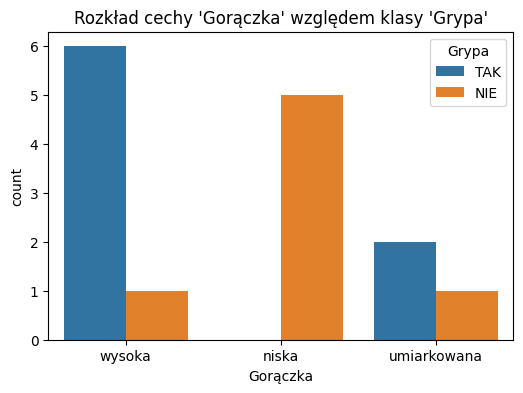

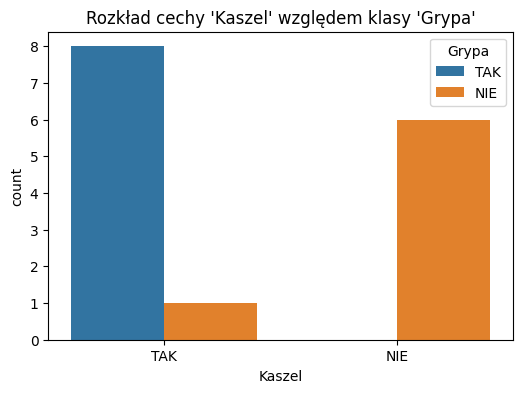

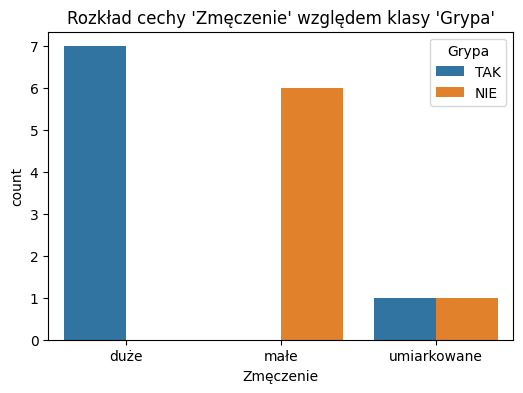

In [21]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_grypa, x=feature, hue='Grypa')
    plt.title(f"Rozkład cechy '{feature}' względem klasy 'Grypa'")
    plt.show()